# ex-5: the rotation angle $\sin^2\angle(\hat w_j, e_j)$

Distribution of the bare rotation term — $\hat w_j$ the $j$-th eigenvector (descending) of
$\hat D = C^{1/2}(F^\top F/n)\,C^{1/2}$, $e_j$ the matching axis — for two calibrations:

| model | $\sigma_j$ (ann.) | $c_j$ |
|---|---|---|
| k=3 canonical | 16%, 8%, 6% | 1.25, 1, 1 |
| k=6 realistic | 16%, 10%, 9%, 8%, 6%, 5% | 1.25, 1, 1, 1, 1, 1 |

Factor returns t6 (variance-matched) and gaussian; $n$ from one month to four years of
trading days; 100k replications per cell. Boxes = IQR, line = median, whiskers = q05/q95.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

SEED, N_REPS, CHUNK = 20260717, 100_000, 5_000
N_EXT = [20, 42, 63, 126, 252, 504, 1008]
Q_LEVELS = [0.05, 0.25, 0.50, 0.75, 0.95]
MODELS = {
    "k3": {"sig": np.array([0.16, 0.08, 0.06]), "c": np.array([1.25, 1.0, 1.0]),
           "labels": ["factor 1", "factor 2", "factor 3"]},
    "k6": {"sig": np.array([0.16, 0.10, 0.09, 0.08, 0.06, 0.05]),
           "c": np.array([1.25, 1, 1, 1, 1, 1.0]),
            "labels": ["factor 1", "factor 2", "factor 3", "factor 4", "factor 5", "factor 6"]
        #    "labels": ["market", "momentum", "value", "size", "quality", "investment"]
           },
}

rows = []
for mname, m in MODELS.items():
    sig, c = m["sig"], m["c"]; k = len(sig)
    for d_idx, dist in enumerate(["t6", "normal"]):
        for nv in N_EXT:
            rng = np.random.default_rng([SEED, nv, d_idx, k])
            rot = np.empty((N_REPS, k))
            for i0 in range(0, N_REPS, CHUNK):
                if dist == "t6":
                    F = rng.standard_t(6, size=(CHUNK, nv, k)) / np.sqrt(1.5) * sig
                else:
                    F = rng.standard_normal(size=(CHUNK, nv, k)) * sig
                X = F * np.sqrt(c)
                Dh = np.einsum("rni,rnj->rij", X, X) / nv
                _, vecs = np.linalg.eigh(Dh)
                W = vecs[:, :, ::-1]
                rot[i0:i0+CHUNK] = 1.0 - np.diagonal(W ** 2, axis1=1, axis2=2)
            for j in range(k):
                for lvl in Q_LEVELS:
                    rows.append({"model": mname, "dist": dist, "n": nv, "factor": j + 1,
                                 "quantile": lvl, "value": np.quantile(rot[:, j], lvl)})

tbl = pd.DataFrame(rows)
tbl.to_csv("nb_outputs/ex5_rotation_angle.csv", index=False)
tbl[(tbl["n"] == 63) & (tbl["quantile"].isin([0.50, 0.95]))].pivot_table(
    index=["model", "factor"], columns=["dist", "quantile"], values="value").round(3)

dist         normal            t6       
quantile       0.50   0.95   0.50   0.95
model factor                            
k3    1       0.005  0.024  0.005  0.028
      2       0.029  0.247  0.031  0.568
      3       0.025  0.246  0.026  0.566
k6    1       0.021  0.071  0.022  0.093
      2       0.241  0.953  0.287  0.990
      3       0.451  0.987  0.576  0.996
      4       0.311  0.958  0.408  0.992
      5       0.181  0.807  0.236  0.971
      6       0.106  0.735  0.113  0.942

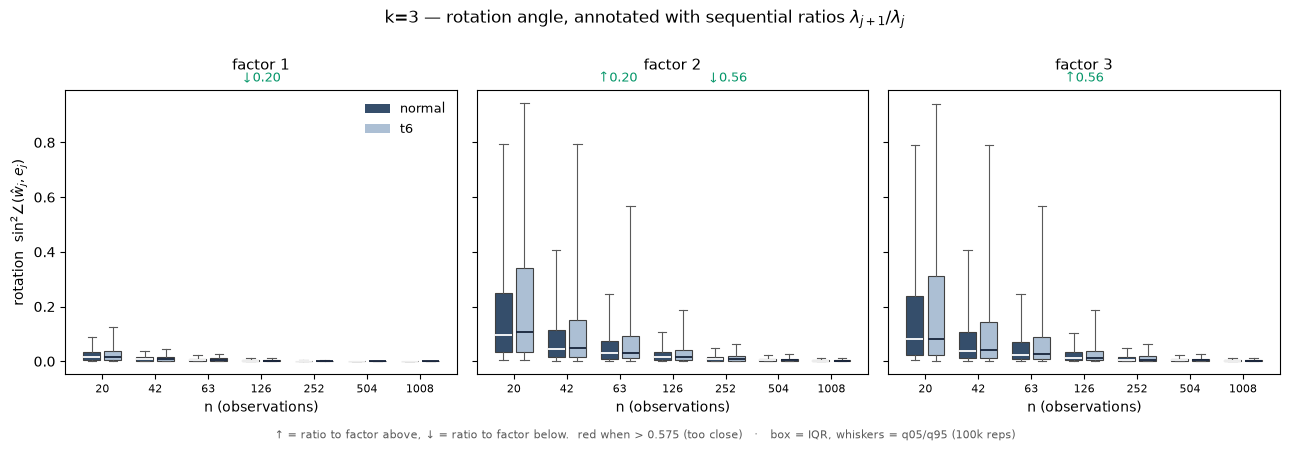

In [2]:
NORMAL, T6 = "#354E6B", "#ACBFD4"
DANGER = 0.575        # seq ratio above this = too close (equiv. lambda ratio < 1.74)

for _m in MODELS.values():                       # limiting eigenvalues + sequential ladder
    _m["lam"] = _m["c"] * _m["sig"] ** 2
    _m["seq"] = _m["lam"][1:] / _m["lam"][:-1]   # f2/f1, f3/f2, ...

def seq_title(ax, m, j, k):
    """Title factor j with the sequential ratios flanking it, each coloured on its own."""
    up   = m["seq"][j-2] if j > 1 else None      # lam_j / lam_{j-1}
    down = m["seq"][j-1] if j < k else None      # lam_{j+1} / lam_j
    ax.set_title(f"factor {j}", fontsize=11, pad=15)
    items = []
    if up   is not None: items.append((f"\u2191{up:.2f}", up))
    if down is not None: items.append((f"\u2193{down:.2f}", down))
    xs = [0.5] if len(items) == 1 else [0.36, 0.64]
    for (label, v), xpos in zip(items, xs):
        ax.text(xpos, 1.02, label, transform=ax.transAxes, ha="center", va="bottom",
                fontsize=9.5, color=("#dc2626" if v > DANGER else "#059669"))

def rotation_bxp(ax, sub_pivot, positions, facecolor, median_color):
    '''Boxplot from precomputed quantiles: box = IQR, line = median, whiskers = q05/q95.'''
    stats = [{"whislo": sub_pivot.loc[nv, 0.05], "q1": sub_pivot.loc[nv, 0.25],
              "med": sub_pivot.loc[nv, 0.50], "q3": sub_pivot.loc[nv, 0.75],
              "whishi": sub_pivot.loc[nv, 0.95], "fliers": []}
             for nv in sub_pivot.index]
    ax.bxp(stats, positions=positions, widths=0.32, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=facecolor, edgecolor="0.25", lw=0.8),
           medianprops=dict(color=median_color, lw=1.3),
           whiskerprops=dict(color="0.35", lw=0.8), capprops=dict(color="0.35", lw=0.8))

def rotation_boxplot_figure(mname, nrows, ncols, figsize, out_name):
    m = MODELS[mname]; k = len(m["sig"])
    x = np.arange(len(N_EXT))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True,
                             squeeze=False)
    for j, ax in enumerate(axes.ravel(), start=1):
        for dist, fc, off, mc in [("normal", NORMAL, -0.2, "white"),
                                  ("t6", T6, 0.2, "#16233A")]:
            sub = (tbl[(tbl["model"] == mname) & (tbl["dist"] == dist)
                       & (tbl["factor"] == j)]
                   .pivot(index="n", columns="quantile", values="value").loc[N_EXT])
            rotation_bxp(ax, sub, x + off, fc, mc)
        seq_title(ax, m, j, k)
        ax.set_xticks(x); ax.set_xticklabels(N_EXT, fontsize=8)
        if j > (nrows - 1) * ncols:
            ax.set_xlabel("n (observations)")
    for row in axes:
        row[0].set_ylabel(r"rotation  sin$^2\angle(\hat w_j, e_j)$")
    axes[0, 0].legend(handles=[Patch(facecolor=NORMAL, label="normal"),
                               Patch(facecolor=T6, label="t6")], frameon=False, fontsize=9)
    fig.suptitle(f"{mname[0]}={mname[1]} — rotation angle, annotated with sequential ratios "
                 r"$\lambda_{j+1}/\lambda_j$", y=1.0)
    fig.text(0.5, -0.02, "\u2191 = ratio to factor above, \u2193 = ratio to factor below.  "
             f"red when > {DANGER} (too close)   \u00b7   box = IQR, whiskers = q05/q95 (100k reps)",
             ha="center", fontsize=8, color="0.35")
    fig.tight_layout()
    fig.savefig(f"nb_outputs/{out_name}", dpi=200, bbox_inches="tight")
    plt.show()

rotation_boxplot_figure("k3", 1, 3, (13, 4.2), "ex5_rotation_boxplots_k3.png")

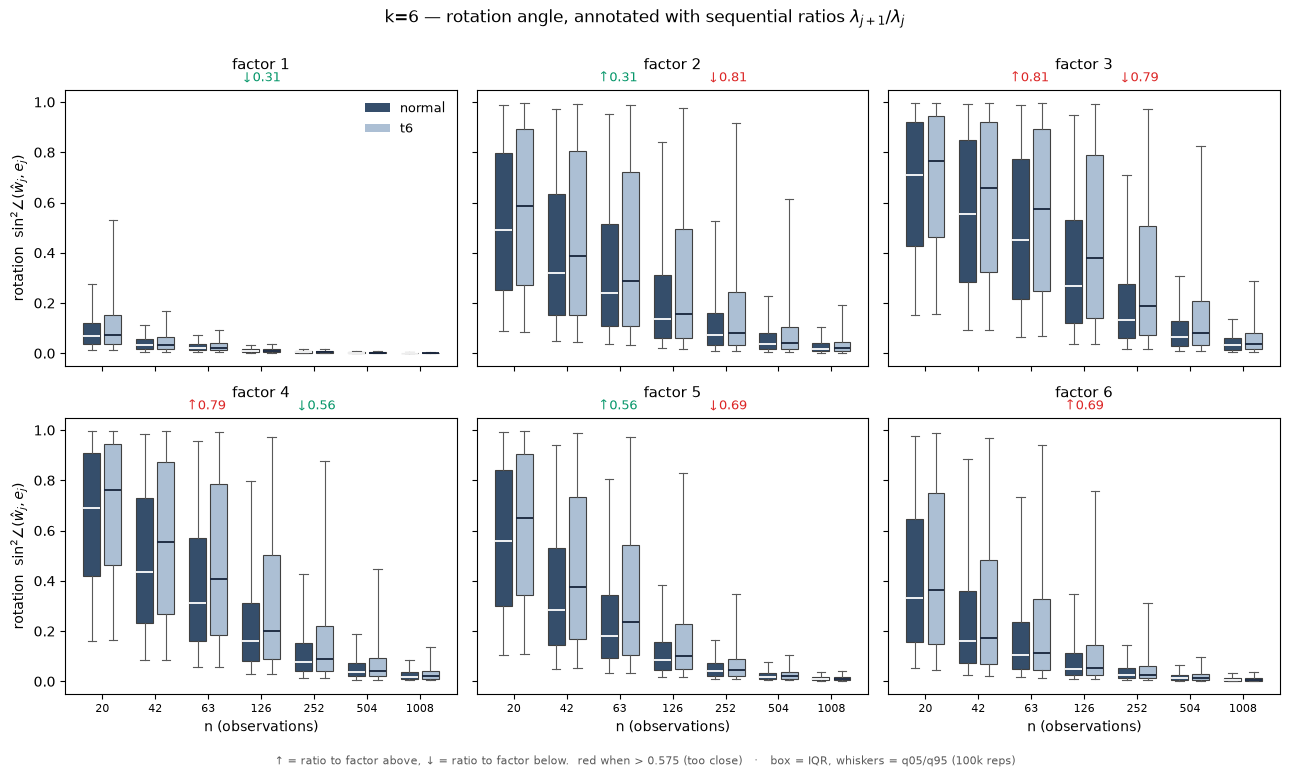

In [3]:
rotation_boxplot_figure("k6", 2, 3, (13, 7.4), "ex5_rotation_boxplots_k6.png")

## Sequential view

Alex's suggestion: rather than reading each factor in isolation, look at the **sequential
ratios** $\lambda_{j+1}/\lambda_j$ (factor2/factor1, factor3/factor2, ...) as a ladder.

Top panel = the $k-1$ ratios, plotted *between* the two factors each one separates.
Bottom panel = the tilt those gaps produce. A factor sits between two gaps, so interior
factors pay for both neighbours while the endpoints only have one.


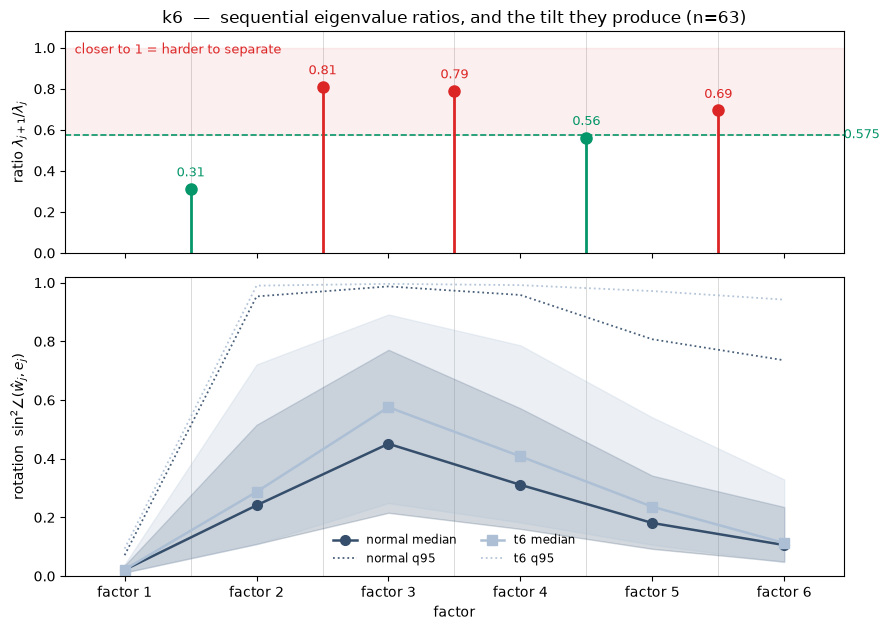

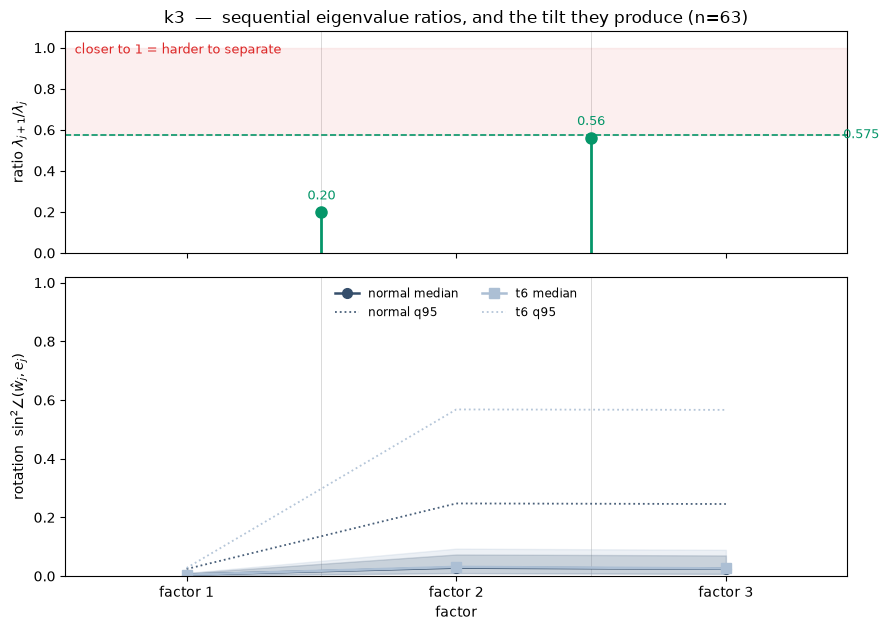

In [4]:
def ratio_ladder_figure(mname, n_show, out_name):
    """Sequential ratio ladder (top) aligned over the tilt it produces (bottom)."""
    m = MODELS[mname]; k = len(m["sig"]); seq = m["seq"]
    fx = np.arange(1, k + 1)               # factor positions
    gx = np.arange(1, k) + 0.5             # gap positions, between factors

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6.4), sharex=True,
                                   gridspec_kw={"height_ratios": [1, 1.35]})
    # top — the ladder
    ax1.axhline(DANGER, color="#059669", ls="--", lw=1.2)
    ax1.text(k + 0.42, DANGER, f" {DANGER}", color="#059669", va="center", fontsize=9)
    ax1.axhspan(DANGER, 1.0, color="#dc2626", alpha=0.07)
    for x, r in zip(gx, seq):
        col = "#dc2626" if r > DANGER else "#059669"
        ax1.vlines(x, 0, r, color=col, lw=2)
        ax1.plot(x, r, "o", color=col, ms=8)
        ax1.annotate(f"{r:.2f}", (x, r), textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=9.5, color=col)
    ax1.set_ylim(0, 1.08); ax1.set_ylabel(r"ratio $\lambda_{j+1}/\lambda_j$")
    ax1.set_title(f"{mname}  —  sequential eigenvalue ratios, and the tilt they produce "
                  f"(n={n_show})", fontsize=12)
    ax1.text(0.012, 0.9, "closer to 1 = harder to separate", transform=ax1.transAxes,
             fontsize=9, color="#dc2626")

    # bottom — the tilt
    for dist, col, mk in [("normal", NORMAL, "o"), ("t6", T6, "s")]:
        sub = (tbl[(tbl["model"] == mname) & (tbl["dist"] == dist) & (tbl["n"] == n_show)]
               .pivot(index="factor", columns="quantile", values="value").loc[fx])
        ax2.fill_between(fx, sub[0.25], sub[0.75], color=col, alpha=0.22)
        ax2.plot(fx, sub[0.50], mk + "-", color=col, lw=1.8, ms=7, label=f"{dist} median")
        ax2.plot(fx, sub[0.95], ":", color=col, lw=1.3, alpha=0.9, label=f"{dist} q95")
    ax2.set_ylim(0, 1.02)
    ax2.set_ylabel(r"rotation  sin$^2\angle(\hat w_j, e_j)$")
    ax2.set_xlabel("factor")
    ax2.set_xticks(fx); ax2.set_xticklabels([f"factor {j}" for j in fx])
    ax2.set_xlim(0.55, k + 0.45)
    ax2.legend(frameon=False, fontsize=8.5, ncol=2)
    for x in gx:                            # link each gap to the factors it separates
        ax1.axvline(x, color="0.85", lw=0.7, zorder=0)
        ax2.axvline(x, color="0.85", lw=0.7, zorder=0)
    fig.tight_layout()
    fig.savefig(f"nb_outputs/{out_name}", dpi=200, bbox_inches="tight")
    plt.show()

ratio_ladder_figure("k6", 63, "ex5_ratio_ladder_k6.png")
ratio_ladder_figure("k3", 63, "ex5_ratio_ladder_k3.png")